In [3]:
# Basado en el sgte post
# https://gsnchez.com/blog/article/El-metodo-de-monte-carlo
# Algunos métodos de pandas_datareader y de yfinance cambiaron y hubo que modificarlo con respecto al original
# Más info acá
# https://www.datasource.ai/uploads/026d8d16ea1e8f4698e716f66e4aa264.html
# https://stackoverflow.com/questions/74835341/pandas-datareader-should-get-stock-market-data-but-returns-error

!pip install yfinance
import pandas as pd
import datetime as dt
import yfinance as yf
from pandas_datareader.nasdaq_trader import get_nasdaq_symbols
from pandas_datareader import data as web
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import seaborn as sns
from matplotlib import style
from google.colab import files    # por si no se puede levantar datos de la web

#style.use('seaborn')
#yf.pdr_override()
symbols = get_nasdaq_symbols()    # cómo se llama cada acción
symbols

TypeError: read_csv() takes 1 positional argument but 2 positional arguments (and 3 keyword-only arguments) were given

In [ ]:
symbols.loc['AMZN']   # Vemos si Amazon está


Nasdaq Traded                                  True
Security Name       Amazon.com, Inc. - Common Stock
Listing Exchange                                  Q
Market Category                                   Q
ETF                                           False
Round Lot Size                                100.0
Test Issue                                    False
Financial Status                                  N
CQS Symbol                                      NaN
NASDAQ Symbol                                  AMZN
NextShares                                    False
Name: AMZN, dtype: object

In [ ]:
symbols.loc['MELI']    #  Mercado Libre

Nasdaq Traded                                    True
Security Name       MercadoLibre, Inc. - Common Stock
Listing Exchange                                    Q
Market Category                                     Q
ETF                                             False
Round Lot Size                                  100.0
Test Issue                                      False
Financial Status                                    N
CQS Symbol                                        NaN
NASDAQ Symbol                                    MELI
NextShares                                      False
Name: MELI, dtype: object

In [4]:
ticker = 'MELI'
desde=dt.datetime(2013,1,1)
hasta=dt.datetime.today()

# Intentos fallidos de descargar precios de acciones
#data = yf.download(ticker, start=desde, end=hasta)
#data = web.DataReader(ticker, data_source='yahoo', start=desde)['Adj Close']
#f = web.get_data_yahoo(ticker, start=desde)

In [5]:
failed=[]
passed=[]
acciones=['AMZN', 'MELI']    # podemos agregar más empresas

def collect_data(accio):
  data = pd.DataFrame()
  for t in accio:
    try:
      data[t] = web.DataReader(t,start=desde)['Adj Close']
      passed.append(t)
    except (IOError, KeyError):
      msg= 'NaN'
      failed.append(t)

  print(data)
  return data


data1=collect_data(acciones)
print('EXITO:', passed)
print('FALLO:', failed)

NotImplementedError: data_source=None is not implemented

In [6]:
#  COMO ALTERNATIVA SI FALLA LA DESCARGA DE DATOS, USAMOS UNOS DATOS DE APPLE QUE TENGO
# Bloque 1
files.upload()

Saving AAPL_2006-01-01_to_2018-01-01.csv to AAPL_2006-01-01_to_2018-01-01.csv


{'AAPL_2006-01-01_to_2018-01-01.csv': b'Date,Open,High,Low,Close,Volume,Name\n2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL\n2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL\n2006-01-05,10.69,10.7,10.54,10.63,112396081,AAPL\n2006-01-06,10.75,10.96,10.65,10.9,176139334,AAPL\n2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL\n2006-01-10,10.89,11.7,10.83,11.55,570088246,AAPL\n2006-01-11,11.98,12.11,11.8,11.99,373548882,AAPL\n2006-01-12,12.14,12.34,11.95,12.04,320201966,AAPL\n2006-01-13,12.14,12.29,12.09,12.23,194153393,AAPL\n2006-01-17,12.24,12.34,11.98,12.1,209215265,AAPL\n2006-01-18,11.87,12.01,11.69,11.78,303279501,AAPL\n2006-01-19,11.61,11.67,11.25,11.29,424100026,AAPL\n2006-01-20,11.33,11.43,10.83,10.87,284634847,AAPL\n2006-01-23,10.87,11.37,10.86,11.1,264942587,AAPL\n2006-01-24,11.25,11.35,10.82,10.86,285661873,AAPL\n2006-01-25,11.06,11.07,10.46,10.6,319019939,AAPL\n2006-01-26,10.65,10.78,10.28,10.33,295599087,AAPL\n2006-01-27,10.42,10.51,10.16,10.29,238597205,AAPL\n2006-01-30,

In [40]:
# Bloque 2
data1 = pd.read_csv('AAPL_2006-01-01_to_2018-01-01.csv')
data1['Date']=pd.to_datetime(data1['Date'])
data1.set_index('Date', inplace=True)
data1


,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL
...,...,...,...,...,...,...
2017-12-22,174.68,175.42,174.50,175.01,16349444,AAPL
2017-12-26,170.80,171.47,169.68,170.57,33185536,AAPL
2017-12-27,170.10,170.78,169.71,170.60,21498213,AAPL


In [41]:
data = data1['Close']    # nos quedamos con el precio de cierre
print(len(data))
data


3019


,Close
Date,
2006-01-03,10.68
2006-01-04,10.71
2006-01-05,10.63
2006-01-06,10.90
2006-01-09,10.86
...,...
2017-12-22,175.01
2017-12-26,170.57
2017-12-27,170.60


In [60]:
ticker='AAPL'

In [42]:
data1

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL
...,...,...,...,...,...,...
2017-12-22,174.68,175.42,174.50,175.01,16349444,AAPL
2017-12-26,170.80,171.47,169.68,170.57,33185536,AAPL
2017-12-27,170.10,170.78,169.71,170.60,21498213,AAPL


In [ ]:
'''data=data1['MELI']
print(len(data))
data'''

2739


Date
2013-01-02      80.506477
2013-01-03      80.956558
2013-01-04      81.005501
2013-01-07      80.839127
2013-01-08      81.631668
                 ...     
2023-11-10    1374.390015
2023-11-13    1378.290039
2023-11-14    1430.510010
2023-11-15    1442.550049
2023-11-16    1469.550049
Name: MELI, Length: 2739, dtype: float64

In [43]:
print(type(data))

<class 'pandas.core.series.Series'>


In [44]:
print(type(data1))

<class 'pandas.core.frame.DataFrame'>


In [45]:
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.pct_change.html#pandas.Series.pct_change
# Computes the fractional change from the immediately previous row by default.
# This is useful in comparing the fraction of change in a time series of elements.
data.pct_change()

,Close
Date,
2006-01-03,NaN
2006-01-04,0.002809
2006-01-05,-0.007470
2006-01-06,0.025400
2006-01-09,-0.003670
...,...
2017-12-22,0.000000
2017-12-26,-0.025370
2017-12-27,0.000176


In [46]:
log_returns = np.log(1+data.pct_change())
u = log_returns.mean()      # media
var = log_returns.var()     # varianza
drift = u - (0.5*var)
stdev = log_returns.std()   # desvío estandar

In [47]:
u

np.float64(0.0009154691527130364)

In [48]:
log_returns

,Close
Date,
2006-01-03,NaN
2006-01-04,0.002805
2006-01-05,-0.007498
2006-01-06,0.025083
2006-01-09,-0.003676
...,...
2017-12-22,0.000000
2017-12-26,-0.025697
2017-12-27,0.000176


In [49]:
var

0.0004178488436018239

In [63]:
days = 30
trials = 10000

In [64]:
# https://docs.scipy.org/doc/scipy/reference/stats.html
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html#scipy.stats.norm
# A normal continuous random variable.
# ppf(q, loc=0, scale=1)     Percent point function (inverse of cdf — percentiles)
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.rand.html
# Create an array of the given shape and populate it with random samples from a uniform distribution over [0, 1)

Z = norm.ppf(np.random.rand(days, trials))
retornos_diarios = np.exp(drift + stdev * Z)
camino_de_precios = np.zeros_like(retornos_diarios)
camino_de_precios[0] = data.iloc[-1]

for t in range(1, days):
    camino_de_precios[t] = camino_de_precios[t-1]*retornos_diarios[t]

print(camino_de_precios)
print(camino_de_precios.shape)

[[169.23       169.23       169.23       ... 169.23       169.23
  169.23      ]
 [165.92593756 166.91385304 170.2350157  ... 168.48465209 169.59187956
  169.68457719]
 [169.68268917 165.71927207 173.43582532 ... 162.87147766 177.23237547
  171.40773636]
 ...
 [169.32661161 167.98639742 164.27318488 ... 134.38656943 193.6366728
  163.3394172 ]
 [167.61346967 171.16833416 169.00032194 ... 132.21597893 194.95993631
  157.52352031]
 [164.97019674 170.93559089 167.4900833  ... 130.12861981 204.63821251
  157.6225348 ]]
(30, 10000)


In [65]:
Z


array([[-1.28896643,  0.3154698 ,  1.34022168, ..., -0.02550984,
         0.06674525, -1.57874053],
       [-0.99913902, -0.70873259,  0.25510283, ..., -0.25050306,
         0.06993477,  0.096667  ],
       [ 1.06069721, -0.38594069,  0.87671189, ..., -1.69214819,
         2.12120714,  0.45972065],
       ...,
       [ 0.97277602,  0.78003934, -2.63071585, ...,  0.76538173,
         0.75644301,  0.37985391],
       [-0.53203209,  0.88340194,  1.35329956, ..., -0.83117052,
         0.29860821, -1.80820297],
       [-0.81219023, -0.1011285 , -0.47369761, ..., -0.81305729,
         2.3356076 , -0.00382424]])

In [66]:
Z.shape

(30, 10000)

In [67]:
df=pd.DataFrame(camino_de_precios)
df_T= df.T
media=df_T.mean().to_frame()

In [68]:
inicio = data.index[-1]   # último día con datos
inicio

Timestamp('2017-12-29 00:00:00')

In [69]:
# cambiamos el índice de camino de precios para empalmar con la serie de precios anteriores
# para eso hay que generar una lista de fechas a partir de la última de la serie de datos con len=days
# https://es.stackoverflow.com/questions/110479/rango-de-fechas-c%c3%b3mo-crear-una-lista-que-contenga-como-items-todos-los-dias-en

nuevo_index=[inicio + dt.timedelta(days = d) for d in range(1,days+1)]
nuevo_index


[Timestamp('2017-12-30 00:00:00'),
 Timestamp('2017-12-31 00:00:00'),
 Timestamp('2018-01-01 00:00:00'),
 Timestamp('2018-01-02 00:00:00'),
 Timestamp('2018-01-03 00:00:00'),
 Timestamp('2018-01-04 00:00:00'),
 Timestamp('2018-01-05 00:00:00'),
 Timestamp('2018-01-06 00:00:00'),
 Timestamp('2018-01-07 00:00:00'),
 Timestamp('2018-01-08 00:00:00'),
 Timestamp('2018-01-09 00:00:00'),
 Timestamp('2018-01-10 00:00:00'),
 Timestamp('2018-01-11 00:00:00'),
 Timestamp('2018-01-12 00:00:00'),
 Timestamp('2018-01-13 00:00:00'),
 Timestamp('2018-01-14 00:00:00'),
 Timestamp('2018-01-15 00:00:00'),
 Timestamp('2018-01-16 00:00:00'),
 Timestamp('2018-01-17 00:00:00'),
 Timestamp('2018-01-18 00:00:00'),
 Timestamp('2018-01-19 00:00:00'),
 Timestamp('2018-01-20 00:00:00'),
 Timestamp('2018-01-21 00:00:00'),
 Timestamp('2018-01-22 00:00:00'),
 Timestamp('2018-01-23 00:00:00'),
 Timestamp('2018-01-24 00:00:00'),
 Timestamp('2018-01-25 00:00:00'),
 Timestamp('2018-01-26 00:00:00'),
 Timestamp('2018-01-

In [70]:
# aplicamos el nuevo índice

df.index=nuevo_index
media.index=nuevo_index
print(df.shape)
df

(30, 10000)


,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
2017-12-30,169.230000,169.230000,169.230000,169.230000,169.230000,169.230000,169.230000,169.230000,169.230000,169.230000,...,169.230000,169.230000,169.230000,169.230000,169.230000,169.230000,169.230000,169.230000,169.230000,169.230000
2017-12-31,165.925938,166.913853,170.235016,168.053393,169.196191,167.501723,173.347229,172.079186,170.503405,175.052942,...,164.954410,172.045399,163.616940,168.930065,166.381898,168.465463,174.791600,168.484652,169.591880,169.684577
2018-01-01,169.682689,165.719272,173.435825,164.225722,171.149448,165.773135,172.629481,175.874893,172.338853,175.428830,...,165.762320,176.973115,162.248160,169.784105,170.166002,167.314209,177.813696,162.871478,177.232375,171.407736
2018-01-02,171.254431,162.279604,174.985848,161.480872,173.536705,165.408190,174.566503,174.326957,170.753711,180.954142,...,167.748926,177.401379,168.201820,167.909555,169.419660,169.817298,175.186537,161.649259,182.305844,170.274679
2018-01-03,173.916016,165.468871,172.274993,162.905554,173.167249,164.938610,180.389054,175.316336,167.304479,180.177808,...,162.122168,178.614301,169.356921,167.645817,166.344137,169.394843,177.363097,157.191951,185.141081,166.873648
2018-01-04,175.403337,157.214102,172.281776,165.658496,174.847766,162.135330,176.527813,180.183118,172.913360,180.605223,...,159.738772,172.290960,166.764310,171.486882,165.007925,171.264657,173.695908,152.371301,180.414129,169.947141
2018-01-05,179.101941,158.155358,172.371247,168.509317,178.800608,159.812231,172.898108,179.964798,172.963309,186.624647,...,153.027460,171.580018,167.626309,177.540213,166.409181,166.661329,175.184404,150.621032,183.955156,171.677121
2018-01-06,179.393156,156.532437,173.611620,166.459591,183.103049,160.876312,163.306628,177.713294,169.772755,181.182355,...,155.585932,171.624354,167.656103,178.526156,158.852466,168.466488,173.514832,147.512225,184.490651,167.461978
2018-01-07,181.777288,157.562069,170.795657,165.900329,185.682708,165.515307,158.045282,181.673310,174.005060,179.921450,...,159.887651,171.314006,166.969857,175.543710,161.704111,169.449873,169.417792,149.073980,180.209018,162.301712
2018-01-08,175.872443,155.242291,163.885666,164.935354,180.506472,169.337216,158.324019,180.583152,170.098004,177.902455,...,159.308256,169.479177,170.179999,176.381015,162.528139,166.926988,170.821262,149.010890,185.792357,161.774723


In [71]:
print(media.shape)
media

(30, 1)


,0
2017-12-30,169.230000
2017-12-31,169.331381
2018-01-01,169.449455
2018-01-02,169.615436
2018-01-03,169.730565
2018-01-04,169.848058
2018-01-05,170.036553
2018-01-06,170.152797
2018-01-07,170.280478
2018-01-08,170.487661


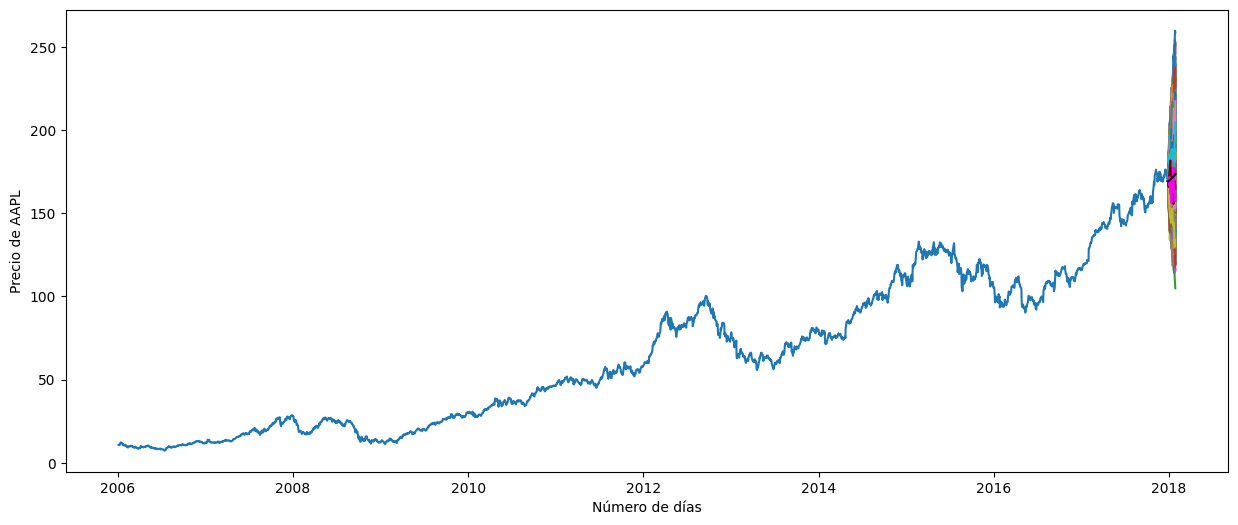

In [72]:
plt.figure(figsize=(15,6))
# figura con la serie completa
plt.plot(data)
plt.plot(df)
plt.plot(df[0],'maroon')
plt.plot(df[9999],'magenta')
plt.plot(media, 'black')
plt.xlabel("Número de días")
plt.ylabel("Precio de " + ticker)
plt.show()



Text(5.069444444444445, 0.5, 'Frecuencia')

<Figure size 1500x600 with 0 Axes>

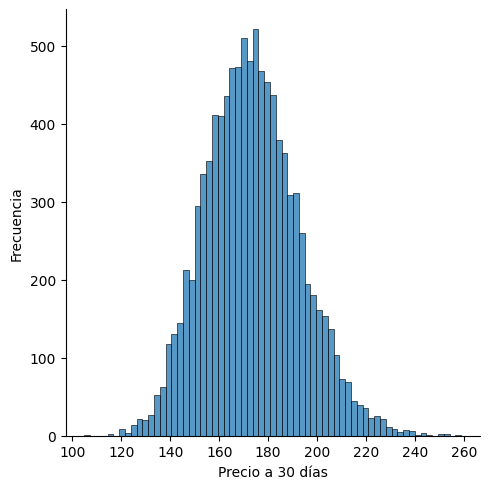

In [73]:
# figura con frecuencia de precios
plt.figure(figsize=(15,6))
sns.displot(df.iloc[-1])
plt.xlabel("Precio a " + str(days) + " días")
plt.ylabel("Frecuencia")

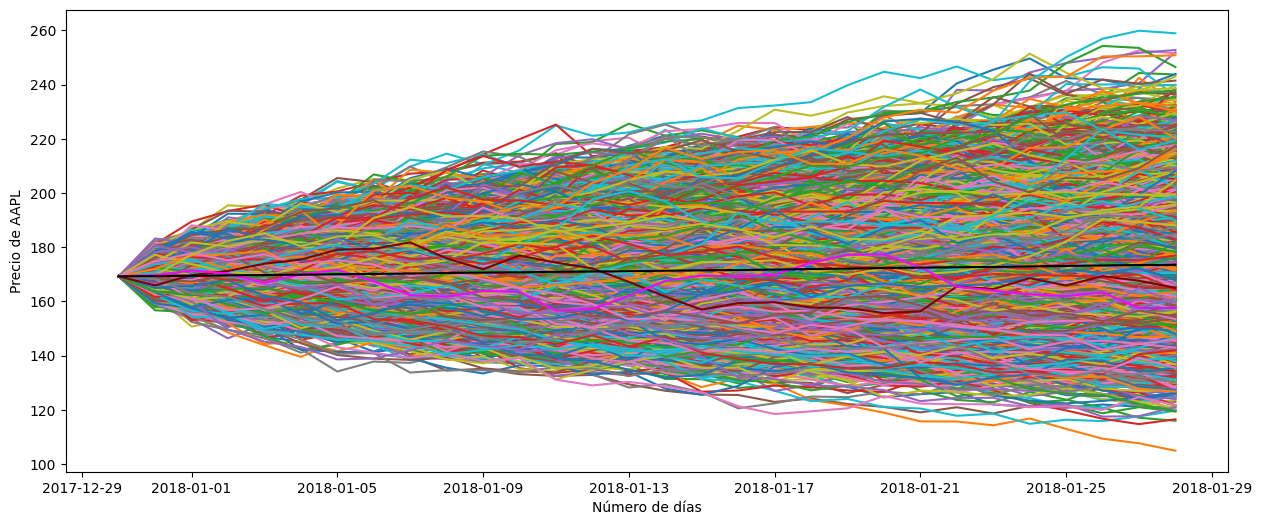

In [74]:
plt.figure(figsize=(15,6))
#figura con las simulaciones solamente
plt.plot(df)
plt.plot(df[0],'maroon')
plt.plot(df[9999],'magenta')
plt.plot(media, 'black')
plt.xlabel("Número de días")
plt.ylabel("Precio de " + ticker)
plt.show()
